In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

# SETUP

floors = np.arange(1, 11)
m      = 10

# Base parameters
kappa_t  = 10.0
kappa_i  = 8.0
v1       = 1.0
v2       = 12.0
Lambda_v = 0.8
D_local    = 0.38
D_nonlocal = 0.72

# Demand distributions
p_sym = np.array([0.02, 0.05, 0.10, 0.20, 0.26, 0.20, 0.10, 0.05, 0.02, 0.01], dtype=float)
p_mod = np.array([0.01, 0.02, 0.03, 0.05, 0.06, 0.10, 0.15, 0.25, 0.23, 0.10], dtype=float)
p_ext = np.array([0.00, 0.00, 0.01, 0.01, 0.02, 0.05, 0.10, 0.20, 0.30, 0.31], dtype=float)
for p in (p_sym, p_mod, p_ext):
    p /= p.sum()

regime_labels = [r'Symmetric $P_z$', r'Moderate Asymmetry $P_z$', r'Extreme Asymmetry $P_z$']
regime_colors = ['#1f77b4', '#9467bd', '#d62728']

def compute_mu_e(k, p_z, v2=v2):
    """Effective elevator service rate at floor k: v2 / E[|k-Z| | Z != k]."""
    pk   = p_z[k - 1]
    z    = np.arange(1, m + 1)
    mask = (z != k)
    if (1.0 - pk) < 1e-12:
        return np.inf
    E_dist = np.dot(p_z[mask], np.abs(k - z[mask])) / (1.0 - pk)
    return v2 / E_dist

def compute_cost(k, p_z,
                 kt_v1=None, ki_v2=None, ki=None,
                 Lambda=None, v2=v2,
                 D_loc=D_local, D_nonloc=D_nonlocal):
    """Full thesis cost function H(k). Returns np.inf if queue is unstable."""
    if kt_v1 is None: kt_v1 = kappa_t / v1
    if ki_v2 is None: ki_v2 = kappa_i / v2
    if ki    is None: ki    = kappa_i
    if Lambda is None: Lambda = Lambda_v

    pk = p_z[k - 1]
    z  = np.arange(1, m + 1)

    T1  = kt_v1 * D_loc    * pk
    T2a = kt_v1 * D_nonloc * (1.0 - pk)
    T2b = ki_v2 * np.dot(p_z, np.abs(k - z))

    if (1.0 - pk) < 1e-12:
        return T1 + T2a + T2b

    mu_e = compute_mu_e(k, p_z, v2)
    if mu_e <= Lambda:
        return np.inf      # queue unstable — flag as infeasible

    T3 = ki * (1.0 - pk) * Lambda / (mu_e * (mu_e - Lambda))
    return T1 + T2a + T2b + T3

def get_costs(p_z, **kwargs):
    return [compute_cost(k, p_z, **kwargs) for k in floors]

def distance_centric_floor(p_z):
    """Heuristic: place hub on the floor with highest demand probability."""
    return floors[np.argmax(p_z)]

def optimal_floor(p_z, **kwargs):
    """Integrated model: floor minimising H(k), ignoring unstable floors."""
    costs = get_costs(p_z, **kwargs)
    finite = [(c, k) for c, k in zip(costs, floors) if np.isfinite(c)]
    return min(finite, key=lambda x: x[0])[1]




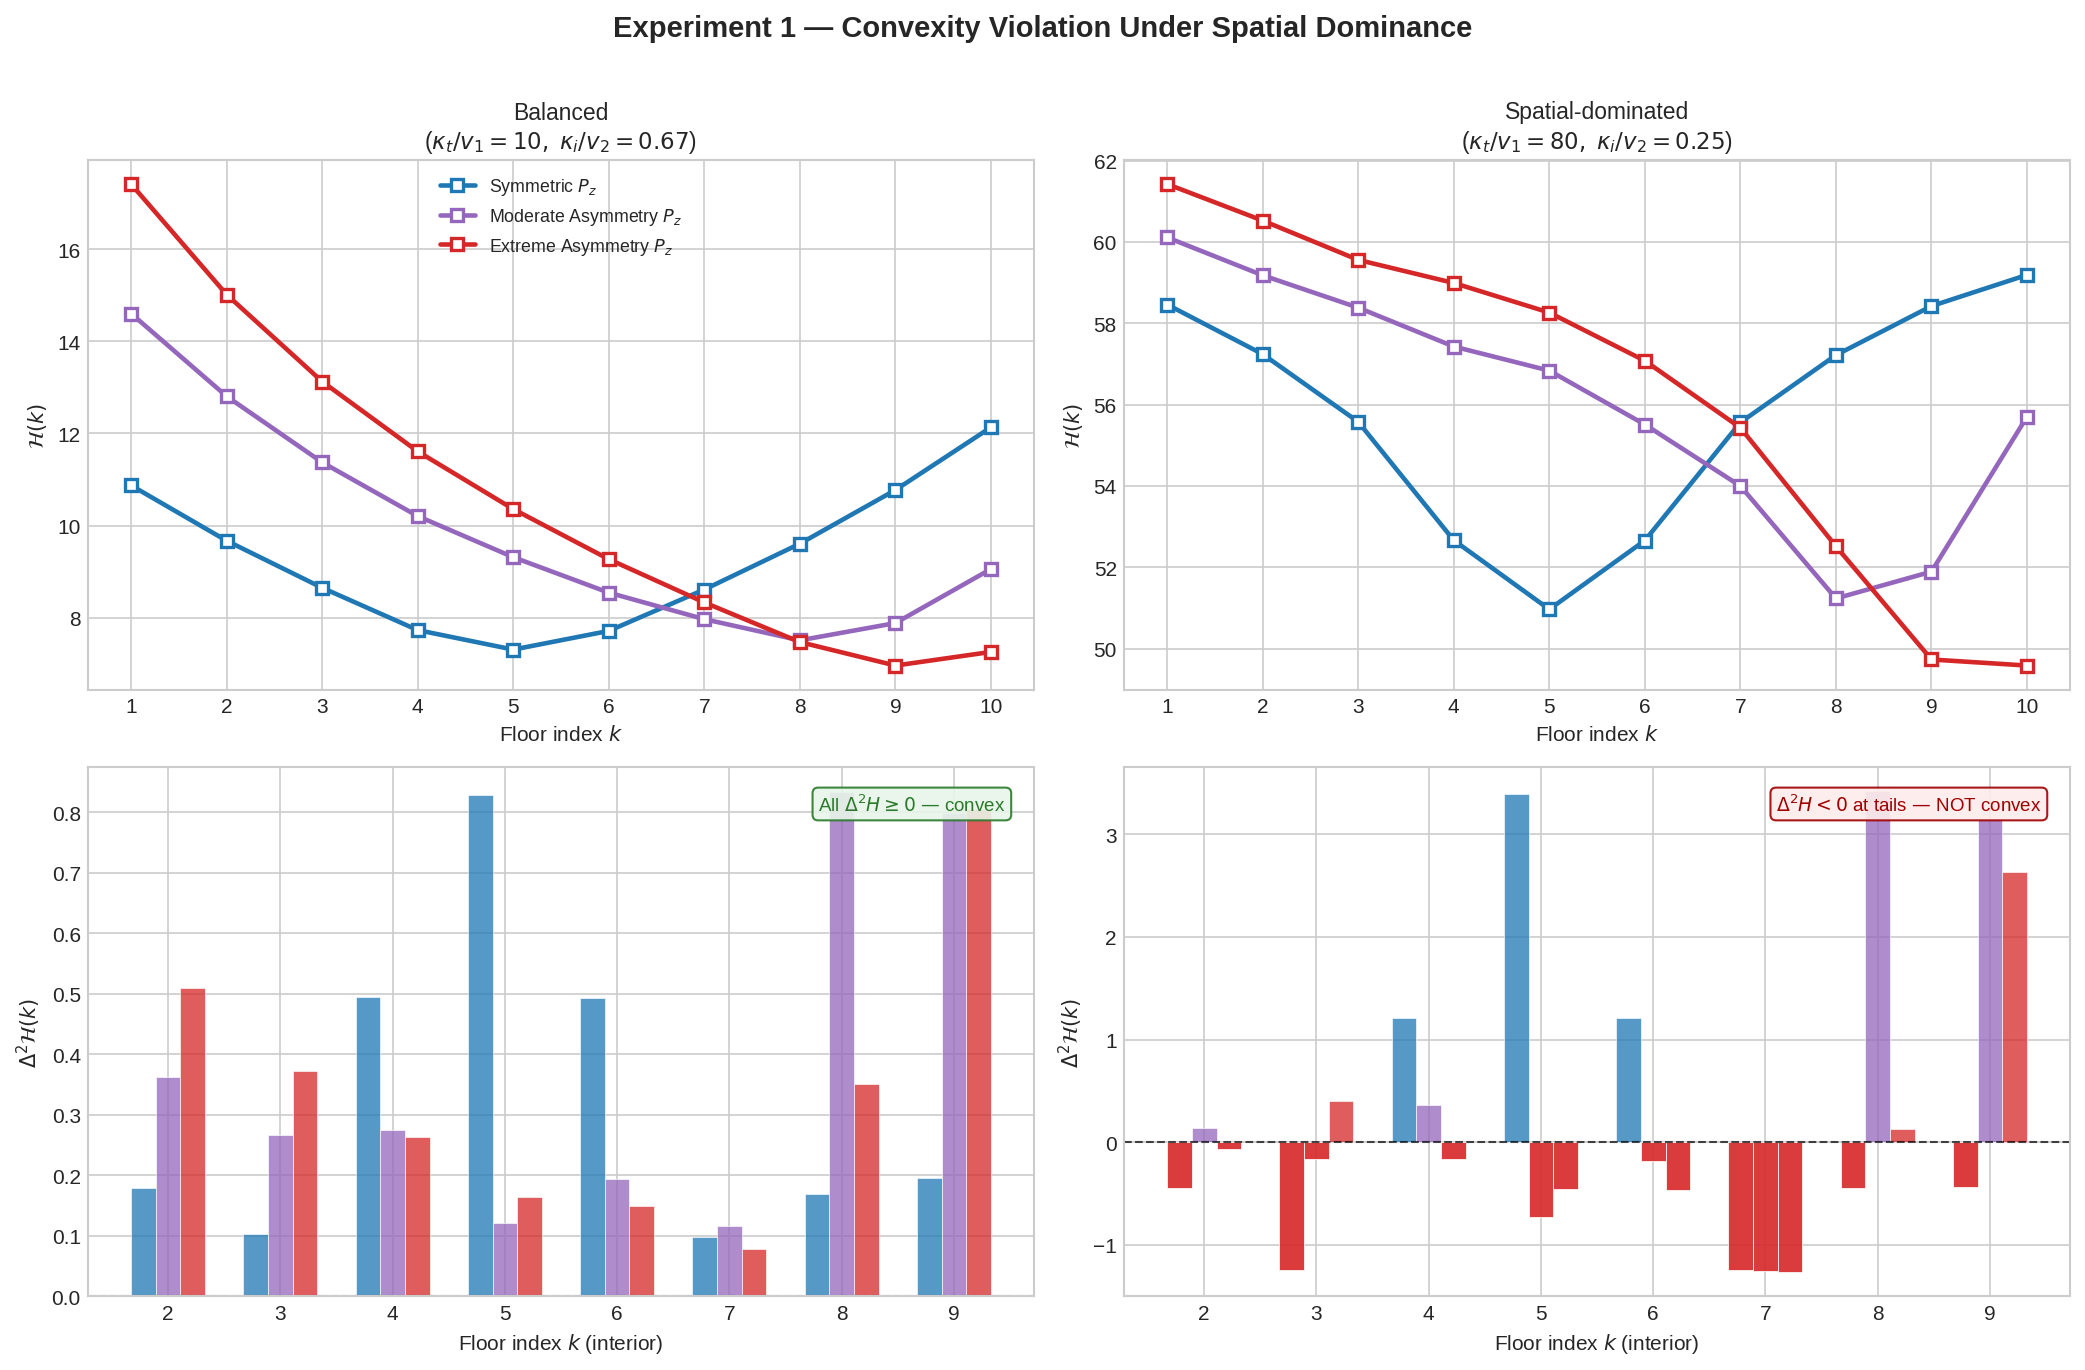

In [ ]:

#  Convexity violation

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 9), dpi=150)
fig.suptitle('Experiment 1 — Convexity Violation Under Spatial Dominance',
             fontsize=14, fontweight='bold', y=1.01)

param_regimes = [
    dict(label='Balanced\n'
                r'($\kappa_t/v_1=10,\;\kappa_i/v_2=0.67$)',
         kt_v1=10.0, ki_v2=0.67, ki=8.0, color='#2ca02c'),
    dict(label='Spatial-dominated\n'
                r'($\kappa_t/v_1=80,\;\kappa_i/v_2=0.25$)',
         kt_v1=80.0, ki_v2=0.25, ki=3.0, color='#d62728'),
]

for col, preg in enumerate(param_regimes):
    ax_top = axes[0][col]
    ax_bot = axes[1][col]
    col_c  = preg['color']

    for p_z, lbl, dem_col in zip([p_sym, p_mod, p_ext], regime_labels, regime_colors):
        costs = get_costs(p_z,
                          kt_v1=preg['kt_v1'], ki_v2=preg['ki_v2'],
                          ki=preg['ki'], Lambda=Lambda_v)
        finite_mask = [np.isfinite(c) for c in costs]
        f_floors = floors[finite_mask]
        f_costs  = [c for c, f in zip(costs, finite_mask) if f]

        ax_top.plot(f_floors, f_costs, color=dem_col, label=lbl,
                    linewidth=2.2, marker='s', markersize=6,
                    markerfacecolor='white', markeredgewidth=1.6)

        if len(f_costs) >= 3:
            d2 = np.diff(np.diff(f_costs))
            interior = f_floors[1:-1]
            bars = ax_bot.bar(interior + regime_colors.index(dem_col) * 0.22 - 0.22,
                              d2, width=0.22, color=dem_col, alpha=0.75,
                              edgecolor='white', linewidth=0.4)

    ax_top.set_title(preg['label'], fontsize=11)
    ax_top.set_xlabel('Floor index $k$', fontsize=10)
    ax_top.set_ylabel(r'$\mathcal{H}(k)$', fontsize=10)
    ax_top.set_xticks(floors)
    if col == 0:
        ax_top.legend(fontsize=8.5, loc='upper center', ncol=1)

    ax_bot.axhline(0, color='black', linewidth=1.0, linestyle='--', alpha=0.7)
    ax_bot.set_xlabel('Floor index $k$ (interior)', fontsize=10)
    ax_bot.set_ylabel(r'$\Delta^2\mathcal{H}(k)$', fontsize=10)
    ax_bot.set_xticks(floors[1:-1])

    # Shade negative bars red to highlight convexity violation
    for patch in ax_bot.patches:
        if patch.get_height() < 0:
            patch.set_facecolor('#d62728')
            patch.set_alpha(0.9)

    status = 'All $\\Delta^2H \\geq 0$ — convex' if col == 0 \
             else '$\\Delta^2H < 0$ at tails — NOT convex'
    status_col = '#2a7a2a' if col == 0 else '#a00000'
    ax_bot.text(0.97, 0.95, status, transform=ax_bot.transAxes,
                ha='right', va='top', fontsize=9, color=status_col,
                bbox=dict(boxstyle='round,pad=0.3',
                          facecolor='#e8f5e9' if col == 0 else '#fdecea',
                          edgecolor=status_col, alpha=0.9))

plt.tight_layout()
plt.show()




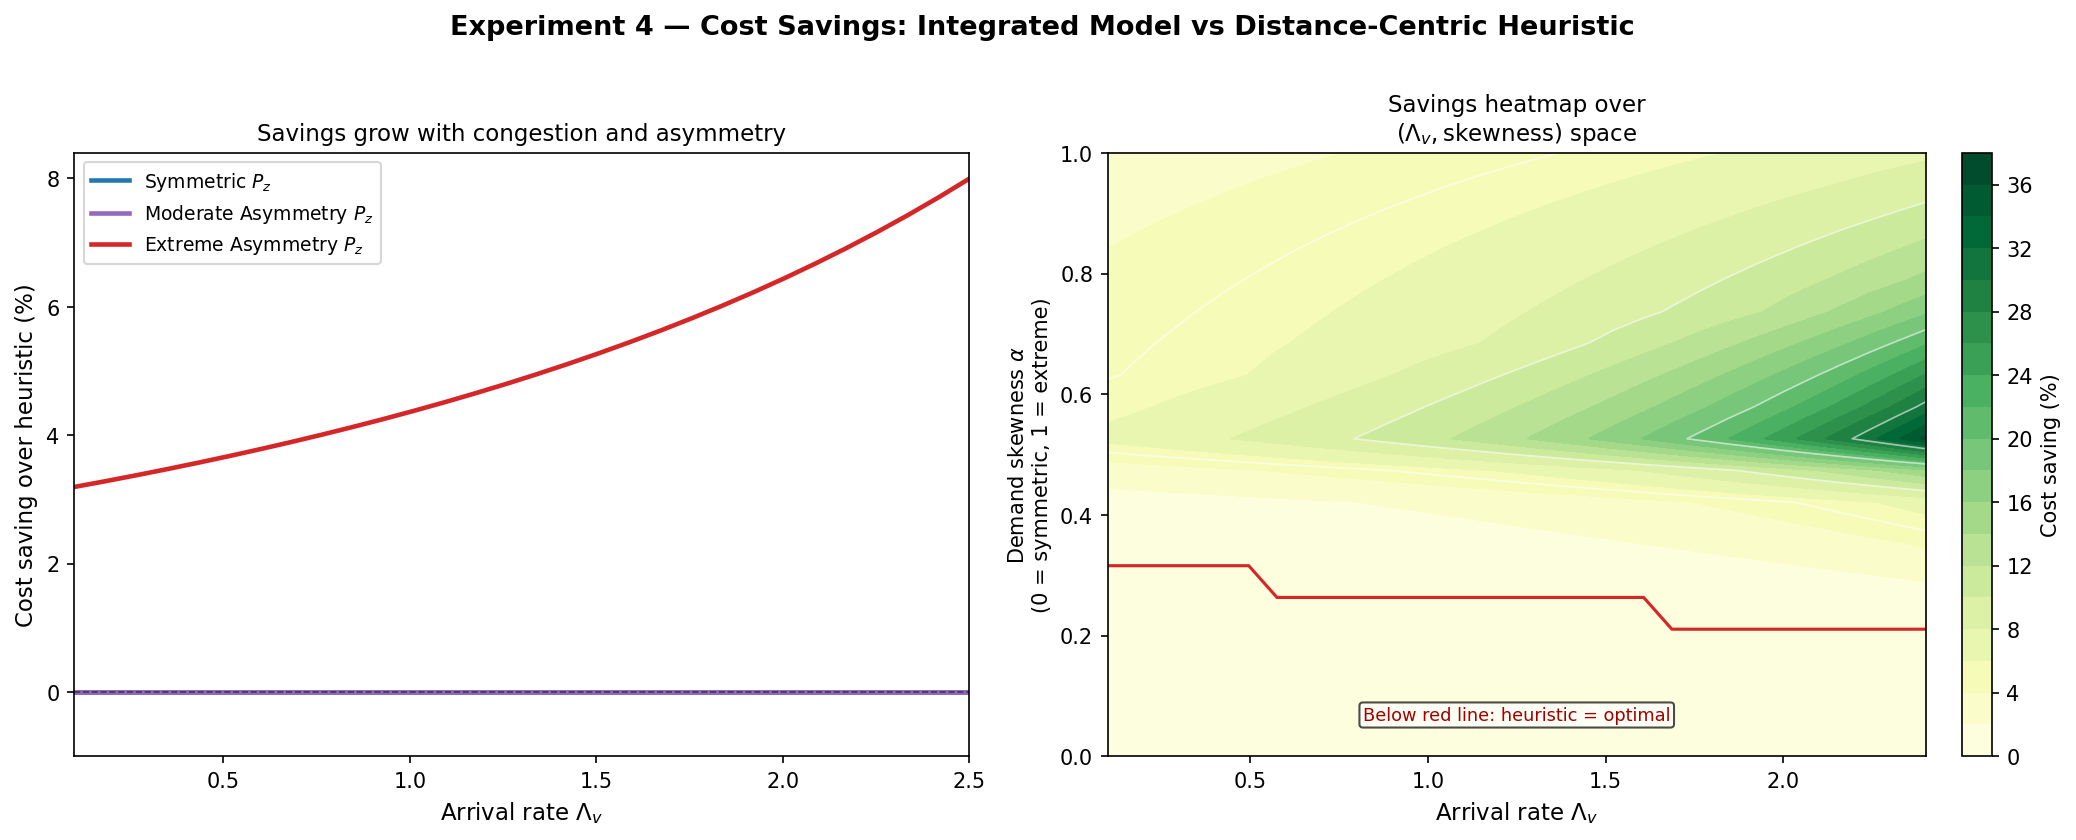

In [3]:

#  Heuristic comparison: integrated model vs distance-centric


lambda_sweep = np.linspace(0.1, 2.5, 30)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), dpi=150)
fig.suptitle('Experiment 4 — Cost Savings: Integrated Model vs Distance-Centric Heuristic',
             fontsize=13, fontweight='bold', y=1.01)

# Panel A: savings curves vs Λ_v for each demand regime
ax = axes[0]
for p_z, lbl, col in zip([p_sym, p_mod, p_ext], regime_labels, regime_colors):
    savings = []
    for lv in lambda_sweep:
        c_star   = optimal_floor(p_z, Lambda=lv)
        c_dist   = distance_centric_floor(p_z)
        h_star   = compute_cost(c_star,   p_z, Lambda=lv)
        h_dist   = compute_cost(c_dist,   p_z, Lambda=lv)
        if np.isfinite(h_star) and np.isfinite(h_dist) and h_dist > 0:
            savings.append(100.0 * (h_dist - h_star) / h_dist)
        else:
            savings.append(np.nan)
    ax.plot(lambda_sweep, savings, color=col, label=lbl,
            linewidth=2.2, marker='None')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel(r'Arrival rate $\Lambda_v$', fontsize=11)
ax.set_ylabel('Cost saving over heuristic (%)', fontsize=11)
ax.set_title('Savings grow with congestion and asymmetry', fontsize=11)
ax.legend(fontsize=9)
ax.set_xlim(lambda_sweep[0], lambda_sweep[-1])
ax.set_ylim(bottom=-1)

# Panel B: savings heatmap over (Λ_v, demand regime skewness parameter)
ax2 = axes[1]
# Vary skewness continuously by interpolating between p_sym and p_ext
alpha_vals  = np.linspace(0, 1, 20)       # 0 = symmetric, 1 = extreme
lambda_vals = np.linspace(0.1, 2.4, 30)
savings_grid = np.zeros((len(alpha_vals), len(lambda_vals)))

for i, alpha in enumerate(alpha_vals):
    p_blend = (1 - alpha) * p_sym + alpha * p_ext
    p_blend /= p_blend.sum()
    for j, lv in enumerate(lambda_vals):
        c_star = optimal_floor(p_blend, Lambda=lv)
        c_dist = distance_centric_floor(p_blend)
        h_star = compute_cost(c_star, p_blend, Lambda=lv)
        h_dist = compute_cost(c_dist, p_blend, Lambda=lv)
        if np.isfinite(h_star) and np.isfinite(h_dist) and h_dist > 0:
            savings_grid[i, j] = 100.0 * (h_dist - h_star) / h_dist
        else:
            savings_grid[i, j] = np.nan

im2 = ax2.contourf(lambda_vals, alpha_vals, savings_grid,
                   levels=20, cmap='YlGn')
ax2.contour(lambda_vals, alpha_vals, savings_grid,
            levels=[5, 10, 20, 30], colors='white',
            linewidths=0.8, alpha=0.6)
ax2.set_xlabel(r'Arrival rate $\Lambda_v$', fontsize=11)
ax2.set_ylabel(r'Demand skewness $\alpha$' + '\n'
               r'(0 = symmetric, 1 = extreme)', fontsize=10)
ax2.set_title('Savings heatmap over\n'
              r'$(\Lambda_v, \text{skewness})$ space', fontsize=11)
cbar2 = fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
cbar2.set_label('Cost saving (%)', fontsize=10)

# Mark zero-saving contour
ax2.contour(lambda_vals, alpha_vals, savings_grid,
            levels=[0], colors='#d62728', linewidths=1.5)
ax2.text(0.5, 0.06, r'Below red line: heuristic = optimal',
         transform=ax2.transAxes, ha='center', fontsize=8.5,
         color='#a00000',
         bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()